C:\Users\Ishit\AppData\Local\Temp\ipykernel_5384\3529520121.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


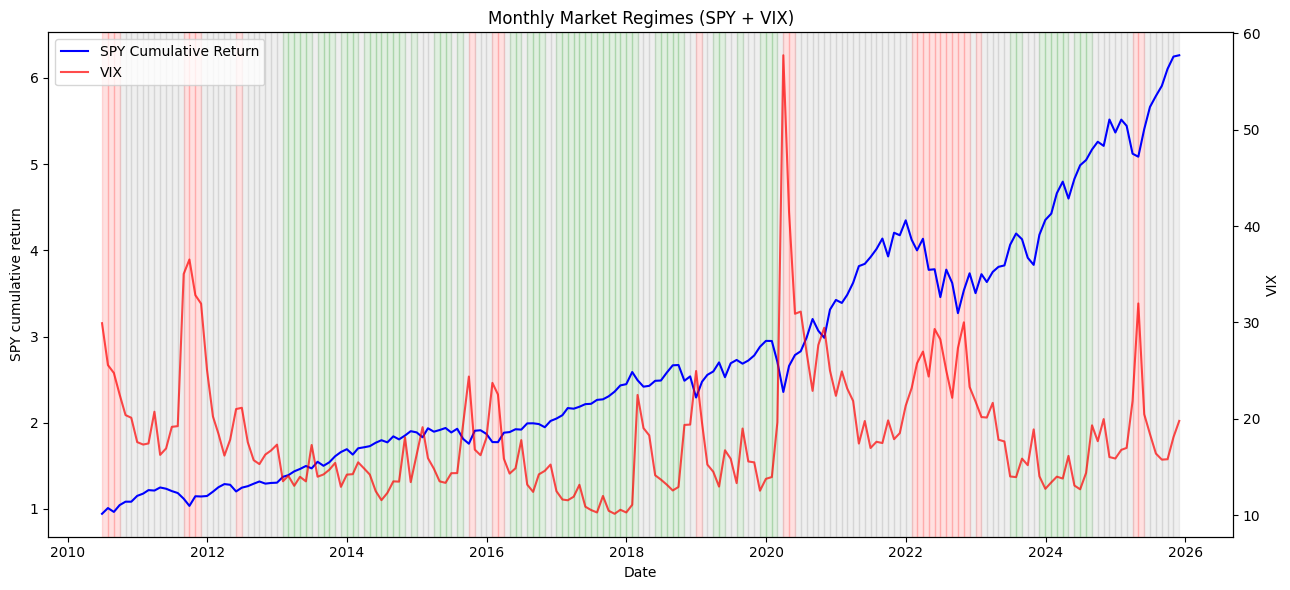

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1. LOAD DATA
# =====================================
spy = pd.read_csv('Data/SPY.csv')      # columns: ['Date', 'SPY']
vix = pd.read_csv('Data/vix.csv')      # columns: ['DATE', 'CLOSE']

spy['Date'] = pd.to_datetime(spy['Date'])
vix['DATE'] = pd.to_datetime(vix['DATE'])

spy = spy.sort_values('Date')
vix = vix.sort_values('DATE')

# =====================================
# 2. CONVERT VIX TO MONTHLY
# =====================================
vix_m = (
    vix.rename(columns={'DATE': 'Date', 'CLOSE': 'VIX'})
       .set_index('Date')['VIX']
       .resample('M')
       .mean()
       .reset_index()
)

# =====================================
# 3. ALIGN SPY TO MONTH-END & MERGE
# =====================================
spy['Date'] = spy['Date'].dt.to_period('M').dt.to_timestamp('M')

df = pd.merge(
    spy,
    vix_m,
    on='Date',
    how='inner'
)

# =====================================
# 4. MONTHLY RETURNS & TREND
# =====================================
df['ret_m'] = df['SPY'].pct_change()
df['MA12'] = df['SPY'].rolling(6).mean()

df = df.dropna().copy()

# =====================================
# 5. DEFINE REGIMES (MONTHLY)
# =====================================
df['regime'] = 'Neutral'

df.loc[
    (df['VIX'] < 15) & (df['SPY'] > df['MA12']),
    'regime'
] = 'Bull'

df.loc[
    (df['VIX'] > 20) & (df['SPY'] < df['MA12']),
    'regime'
] = 'Bear'

# =====================================
# 6. MERGE REGIMES BACK INTO SPY FILE
# =====================================
spy_regime = pd.merge(
    spy,
    df[['Date', 'regime']],
    on='Date',
    how='left'
)

# =====================================
# 7. PLOT: SPY + REGIME SHADING + VIX
# =====================================
df['cum_ret'] = (1 + df['ret_m']).cumprod()

colors = {'Bull': 'green', 'Bear': 'red', 'Neutral': 'gray'}

fig, ax1 = plt.subplots(figsize=(13, 6))

# Regime shading
for i in range(len(df) - 1):
    ax1.axvspan(
        df['Date'].iloc[i],
        df['Date'].iloc[i + 1],
        color=colors[df['regime'].iloc[i]],
        alpha=0.12
    )

# SPY cumulative return
line_spy, = ax1.plot(
    df['Date'],
    df['cum_ret'],
    color='blue',
    label='SPY Cumulative Return'
)
ax1.set_ylabel('SPY cumulative return')
ax1.set_xlabel('Date')

# VIX (secondary axis)
ax2 = ax1.twinx()
line_vix, = ax2.plot(
    df['Date'],
    df['VIX'],
    color='red',
    alpha=0.7,
    label='VIX'
)
ax2.set_ylabel('VIX')

# Combined legend
ax1.legend(
    handles=[line_spy, line_vix],
    loc='upper left'
)

ax1.set_title('Monthly Market Regimes (SPY + VIX)')
plt.tight_layout()
plt.show()


In [7]:
df[["Date","SPY","regime"]].to_csv('Data/spy_with_regimes.csv', index=False)

In [2]:
df["regime"].value_counts()

NameError: name 'df' is not defined

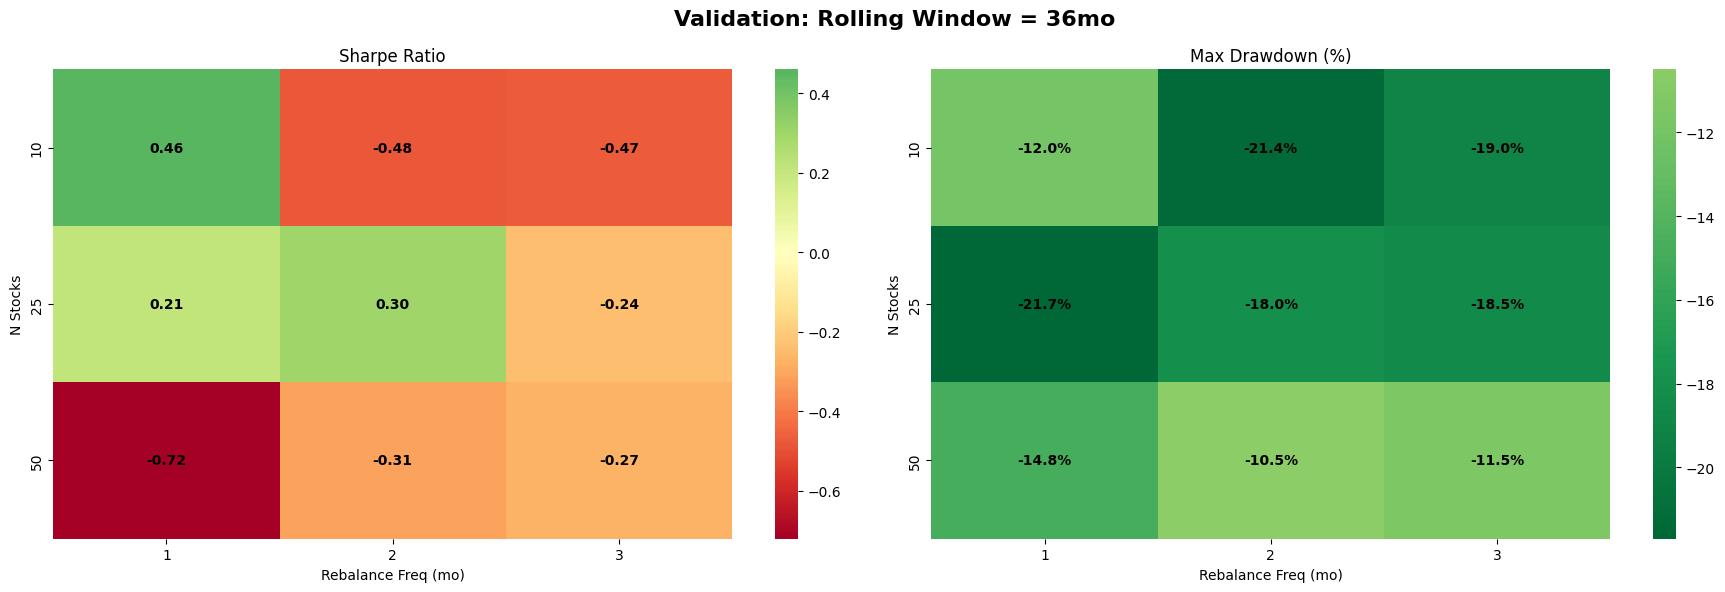

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the data based on the image
# X-axis labels (updated as requested)
freq_labels = [1, 2, 3]
# Y-axis labels
n_stocks_labels = [10, 25, 50]

# Data for Sharpe Ratio
data_sharpe = np.array([
    [0.46, -0.48, -0.47],
    [0.21, 0.30, -0.24],
    [-0.72, -0.31, -0.27]
])

# Data for Total Return (%)
data_return = np.array([
    [10.1, 7.9, -4.6],
    [7.6, 5.8, -2.2],
    [-5.5,  0.2, -0.3]
])

# Data for Max Drawdown (%)
data_drawdown = np.array([
    [-12.0, -21.4, -19.0],
    [-21.7, -18.0, -18.5],
    [-14.8, -10.5, -11.5]
])

# Create DataFrames
df_sharpe = pd.DataFrame(data_sharpe, index=n_stocks_labels, columns=freq_labels)
df_return = pd.DataFrame(data_return, index=n_stocks_labels, columns=freq_labels)
df_drawdown = pd.DataFrame(data_drawdown, index=n_stocks_labels, columns=freq_labels)

# 2. Setup the Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validation: Rolling Window = 36mo', fontsize=16, fontweight='bold')

# Helper function to create heatmap
def create_heatmap(ax, data, title, fmt, cmap, cbar_label=''):
    sns.heatmap(data, ax=ax, annot=True, fmt=fmt, cmap=cmap, center=0,
                cbar=True, annot_kws={"weight": "bold", "color": "black"})
    ax.set_title(title)
    ax.set_xlabel('Rebalance Freq (mo)')
    ax.set_ylabel('N Stocks')

# Plot 1: Sharpe Ratio
# Normal Red-Yellow-Green (Higher is Green/Better)
create_heatmap(axes[0], df_sharpe, 'Sharpe Ratio', '.2f', 'RdYlGn')

# Plot 2: Total Return
# Normal Red-Yellow-Green (Higher is Green/Better)
# create_heatmap(axes[1], df_return, 'Total Return (%)', '.1f', 'RdYlGn')

# Plot 3: Max Drawdown
# NOTE: In the original image, more negative values (e.g., -21%) were Green.
# Standard logic usually implies closer to 0 is better, but to match the image
# exactly, we reverse the colormap so lower (more negative) values are Green.
create_heatmap(axes[1], df_drawdown, 'Max Drawdown (%)', '.1f', 'RdYlGn_r')

# Fix formatting for percentage signs in annotations for plots 2 and 3
for ax in axes[1:]:
    for t in ax.texts:
        t.set_text(t.get_text() + "%")

plt.tight_layout()
plt.show()